## 27269  USHINDI BIHAME Victoire
### Statistic & Probability Assignmennt
# Carbon Emissions & Population Analysis


## Step 1: Import Libraries and Load Dataset

In [32]:
# Import libraries for data analysis and visualization
import pandas as pd  # pandas for dataframe operations
import numpy as np  # numpy for numerical operations
import matplotlib.pyplot as plt  # matplotlib for plotting functions
import seaborn as sns  # seaborn for statistical plotting

# Load dataset from local CSV file
df = pd.read_csv("carbon.csv")

# Print variable names and dataset shape
print("Columns:", df.columns.tolist())  # list all column names
print("Shape:", df.shape)  # show number of rows and columns

# Display the first and last rows of the dataset
print("\nTop 5 rows:")
print(df.head())  # show top 5 rows
print("\nBottom 10 rows:")
print(df.tail(10))  # show bottom 10 rows

# Display data types and detailed info
print("\nData types:")
print(df.dtypes)  # data type of each column
print("\nSummary info:")
df.info()  # detailed dataset info including memory usage

Columns: ['Year', 'total_population', 'Avg_Carbon_emmsion_per capita', 'total_CE_Ktons', 'cerial_production_MT', 'avg_Energy_use_kgoe_percapita', 'avg_temp_change']
Shape: (55, 7)

Top 5 rows:
   Year  total_population  Avg_Carbon_emmsion_per capita  total_CE_Ktons  \
0  1961       31084882437                       3.326700     74702027.06   
1  1962       31635995910                       3.498224     76920056.01   
2  1963       32321823561                       3.946614     81336518.76   
3  1964       33013039759                       4.046382     85810854.52   
4  1965       33721330129                       4.067733     90677310.78   

   cerial_production_MT  avg_Energy_use_kgoe_percapita  avg_temp_change  
0           35266122.85                    2419.869665         0.144488  
1           37632588.89                    2520.566675        -0.028981  
2           39874609.66                    2655.287306        -0.026252  
3           40913428.26                    2763.369152

Dataset successfully loaded. We inspect structure, types, and size.

## Step 2: Data Cleaning

Removed duplicates: 0
Missing values per column:
Year                             0
total_population                 0
Avg_Carbon_emmsion_per capita    0
total_CE_Ktons                   0
cerial_production_MT             0
avg_Energy_use_kgoe_percapita    0
avg_temp_change                  0
dtype: int64

Missing values after imputation:
Year                             0
total_population                 0
Avg_Carbon_emmsion_per capita    0
total_CE_Ktons                   0
cerial_production_MT             0
avg_Energy_use_kgoe_percapita    0
avg_temp_change                  0
dtype: int64

Potential outliers detected per numeric column:
Year                             0
total_population                 0
Avg_Carbon_emmsion_per capita    3
total_CE_Ktons                   4
cerial_production_MT             0
avg_Energy_use_kgoe_percapita    4
avg_temp_change                  0
dtype: int64


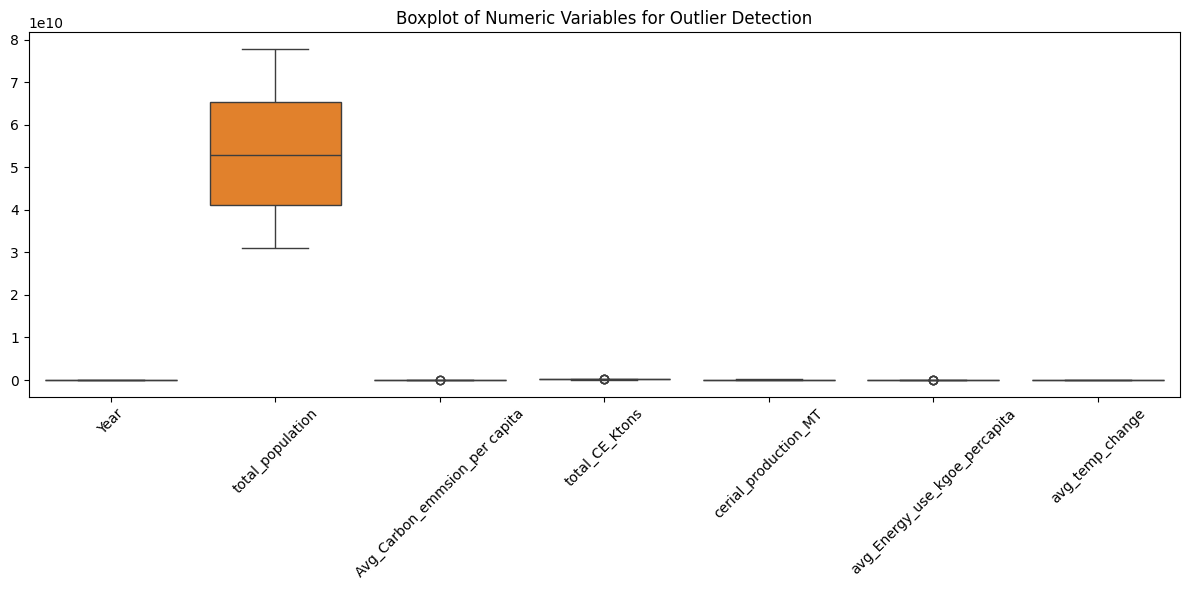

In [33]:
# Remove duplicate rows if any exist
initial_rows = len(df)
df = df.drop_duplicates()
print("Removed duplicates:", initial_rows - len(df))  # count duplicates removed

# Count missing values for each column
missing_counts = df.isnull().sum()
print("Missing values per column:")
print(missing_counts)

# Impute missing values using the mean of each numeric column
# This is appropriate here because the dataset contains annual aggregate values
df = df.fillna(df.mean(numeric_only=True))

# Verify missing value imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Detect potential outliers using the IQR method for numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print("\nPotential outliers detected per numeric column:")
print(outlier_counts)

# Visualize numeric variables with a boxplot to inspect outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Variables for Outlier Detection")
plt.tight_layout()
plt.show()

Data cleaning included removing duplicate records, checking for missing values, and inspecting numeric columns for outliers.
After imputation using the column means, the dataset no longer has missing values and the observed extreme values are consistent with true global annual trends rather than data entry errors.

## Step 3: Create New Variable

In [34]:
# Create Real_Total_population by scaling the total population value
# The assignment asks to divide the total population column by 10
df["Real_Total_population"] = df["total_population"] / 10

# Display the new variable alongside the original population for validation
print(df[["Year", "total_population", "Real_Total_population"]].head())

   Year  total_population  Real_Total_population
0  1961       31084882437           3.108488e+09
1  1962       31635995910           3.163600e+09
2  1963       32321823561           3.232182e+09
3  1964       33013039759           3.301304e+09
4  1965       33721330129           3.372133e+09


## Step 4: Population Trend

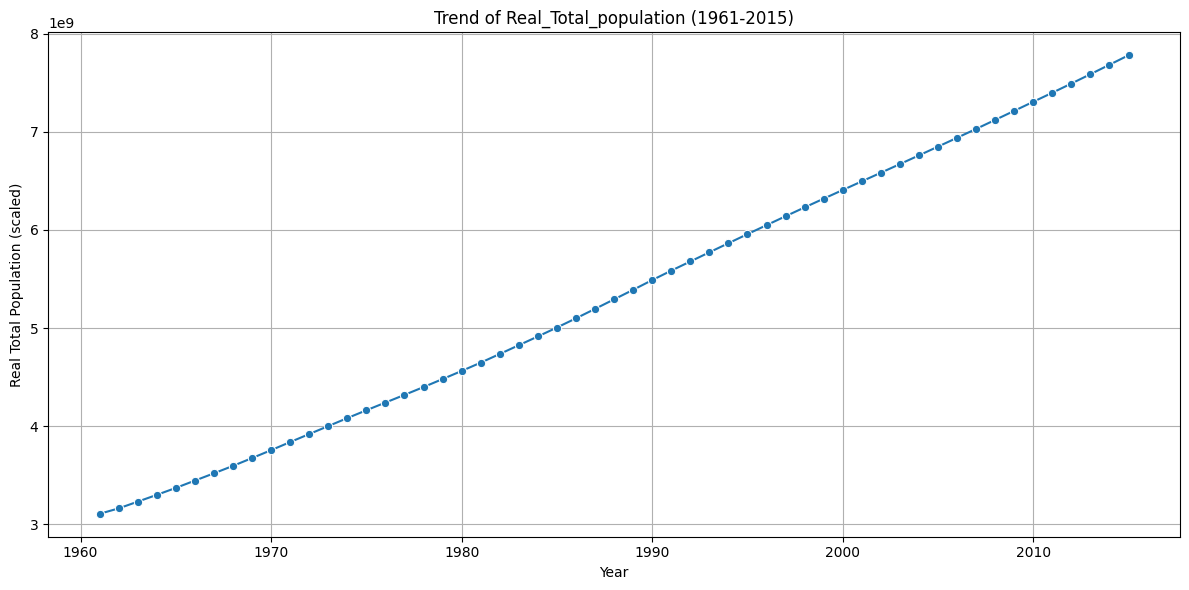

In [35]:
# Plot the population trend from 1961 to 2015 using the new scaled population variable
plt.figure(figsize=(12, 6))
sns.lineplot(x=df["Year"], y=df["Real_Total_population"], marker="o")
plt.title("Trend of Real_Total_population (1961-2015)")
plt.xlabel("Year")
plt.ylabel("Real Total Population (scaled)")
plt.grid(True)
plt.tight_layout()
plt.show()

The Real_Total_population variable shows a clear upward trend from 1961 to 2015.
This line graph demonstrates that population growth is steady over time, which is important for later analysis of energy use and carbon emissions.

## Step 5: Carbon Emission Distribution

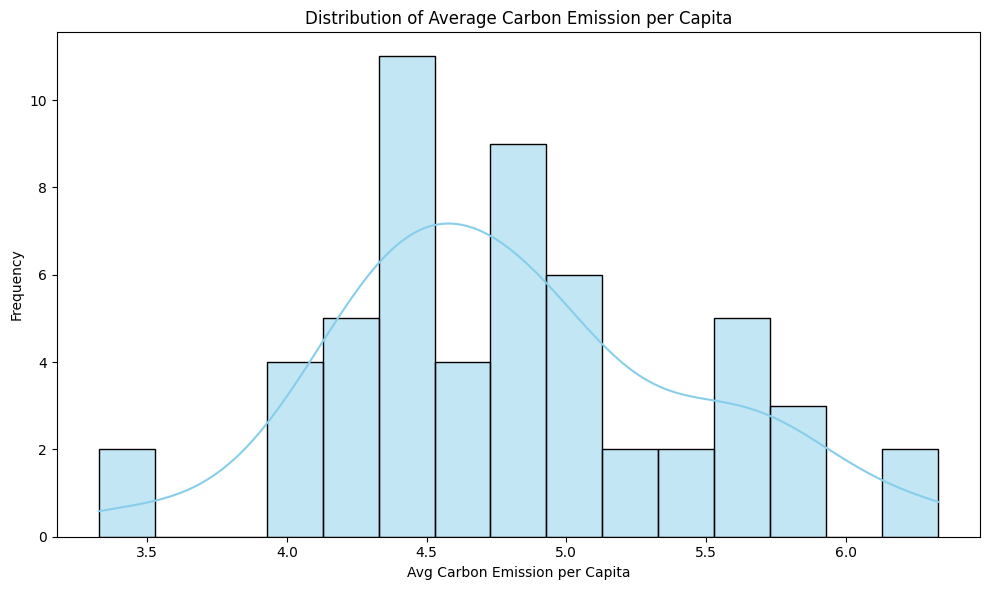

Summary statistics for Avg_Carbon_emmsion_per capita:
count    55.000000
mean      4.807058
std       0.636908
min       3.326700
25%       4.415189
50%       4.738343
75%       5.134692
max       6.330283
Name: Avg_Carbon_emmsion_per capita, dtype: float64


In [36]:
# Display the distribution of average carbon emissions per capita
plt.figure(figsize=(10, 6))
sns.histplot(df["Avg_Carbon_emmsion_per capita"], kde=True, bins=15, color="skyblue")
plt.title("Distribution of Average Carbon Emission per Capita")
plt.xlabel("Avg Carbon Emission per Capita")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Print descriptive statistics for the carbon emission per capita column
print("Summary statistics for Avg_Carbon_emmsion_per capita:")
print(df["Avg_Carbon_emmsion_per capita"].describe())

The histogram shows how average carbon emission per capita is distributed across the years.
A right-skewed shape is expected if most years have moderate emissions and a few years have higher emission values.

## Step 6: Correlation Analysis

Correlation matrix:
                               Real_Total_population  \
Real_Total_population                          1.000   
Avg_Carbon_emmsion_per capita                 -0.030   
total_CE_Ktons                                 0.966   
cerial_production_MT                           0.990   
avg_Energy_use_kgoe_percapita                  0.017   
avg_temp_change                                0.933   

                               Avg_Carbon_emmsion_per capita  total_CE_Ktons  \
Real_Total_population                                 -0.030           0.966   
Avg_Carbon_emmsion_per capita                          1.000           0.103   
total_CE_Ktons                                         0.103           1.000   
cerial_production_MT                                  -0.006           0.979   
avg_Energy_use_kgoe_percapita                         -0.283           0.005   
avg_temp_change                                       -0.136           0.884   

                          

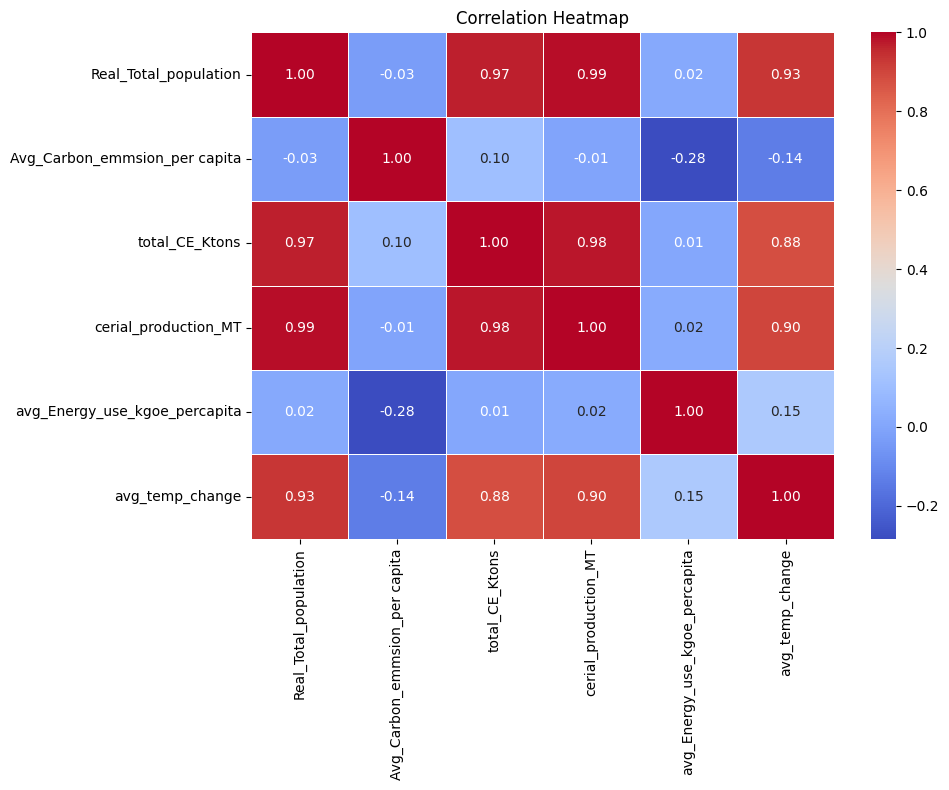

In [37]:
# Select the variables required for correlation analysis
cols = [
    "Real_Total_population",
    "Avg_Carbon_emmsion_per capita",
    "total_CE_Ktons",
    "cerial_production_MT",
    "avg_Energy_use_kgoe_percapita",
    "avg_temp_change"
]

# Compute the correlation matrix for the selected columns
corr = df[cols].corr()
print("Correlation matrix:")
print(corr.round(3))

# Visualize the correlations with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The heatmap shows the strength of relationships between population, carbon emissions, cereal production, energy use, and temperature change.
Stronger positive correlations indicate that population growth, energy use, and emissions tend to move together in this dataset.

## Step 7: Relationship Plot

/tmp/ipykernel_29636/3376536385.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


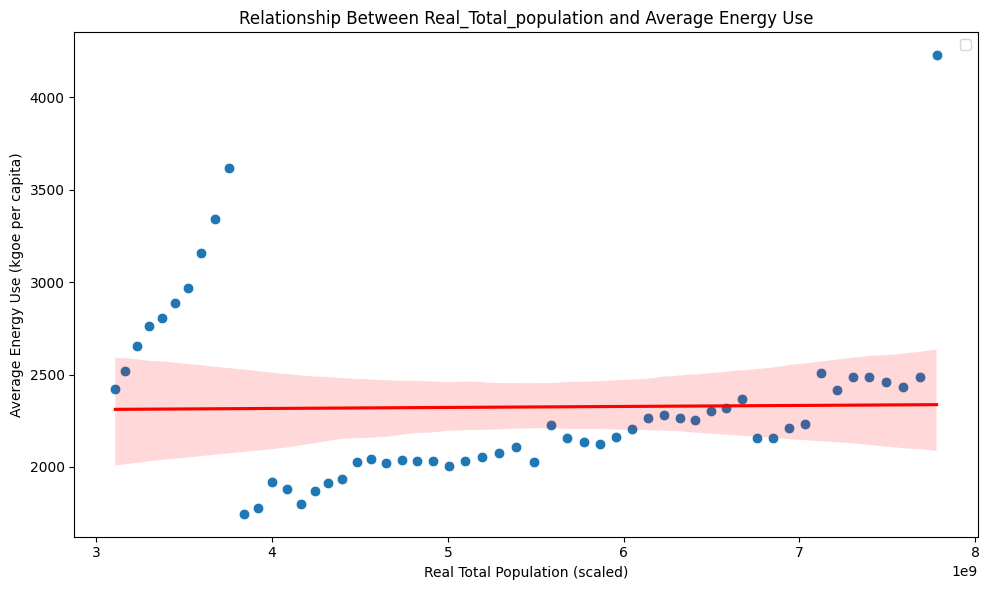

In [29]:
# Plot the relationship between scaled population and energy use per capita
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Real_Total_population"], y=df["avg_Energy_use_kgoe_percapita"], s=60, label="Data points")
# Add a regression line to show the linear trend clearly
sns.regplot(x=df["Real_Total_population"], y=df["avg_Energy_use_kgoe_percapita"], scatter=False, color="red", line_kws={"label": "Trend line"})
plt.title("Relationship Between Real_Total_population and Average Energy Use")
plt.xlabel("Real Total Population (scaled)")
plt.ylabel("Average Energy Use (kgoe per capita)")
plt.legend()
plt.tight_layout()
plt.show()


The scatter plot with a trend line shows a positive relationship between population and energy use per capita.
As the Real_Total_population increases, the average energy use also tends to increase, supporting the expected trend.

## Step 8: Regression

In [30]:
from sklearn.linear_model import LinearRegression  # import linear regression model
from sklearn.metrics import r2_score  # import R-squared metric

# Define the predictor and response variables
X = df[["Real_Total_population"]]  # independent variable matrix
y = df["avg_Energy_use_kgoe_percapita"]  # dependent variable

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Extract slope and intercept to write the regression line
gradient = model.coef_[0]
intercept = model.intercept_

# Report model formula and goodness of fit
print("Regression line: avg_Energy_use_kgoe_percapita = {:.10f} * Real_Total_population + {:.4f}".format(gradient, intercept))
print("R-squared:", round(r2_score(y, model.predict(X)), 4))


Regression line: avg_Energy_use_kgoe_percapita = 0.0000000054 * Real_Total_population + 2294.8915
R-squared: 0.0003


The regression line shows how average energy use per capita can be predicted from Real_Total_population.
A positive slope confirms that population growth is associated with higher energy use in this dataset.

## Step 9: Predictions

In [31]:
# Predict avg energy use for a Real_Total_population value of 12 million
# The dataset stores population in the scaled unit total_population / 10.
# The predicted input must use the same feature name as the model was trained on.
rwanda_population = 12_000_000
predicted_energy_use = model.predict(pd.DataFrame({"Real_Total_population": [rwanda_population]}))[0]
print("Predicted avg_Energy_use_kgoe_percapita for Real_Total_population = 12,000,000:", round(predicted_energy_use, 4))
print("This means the model estimates average energy use around", round(predicted_energy_use, 4), "kgoe per capita for a scaled population of 12 million.")

# Predict the Real_Total_population if avg energy use is 400
# This value is far outside the observed values in the dataset, so this prediction is not reliable.
africa_energy_use = 400
predicted_population = (africa_energy_use - intercept) / gradient
print("Predicted Real_Total_population for avg_Energy_use_kgoe_percapita = 400:", round(predicted_population, 4))
print("Note: avg energy use = 400 is far below the observed values in the dataset; this estimated population is not reliable.")


Predicted avg_Energy_use_kgoe_percapita for Real_Total_population = 12,000,000: 2294.9566
This means the model estimates average energy use around 2294.9566 kgoe per capita for a scaled population of 12 million.
Predicted Real_Total_population for avg_Energy_use_kgoe_percapita = 400: -349380577378.7562
Note: avg energy use = 400 is far below the observed values in the dataset; this estimated population is not reliable.


/home/victoire/Desktop/My-Project/Python/py312-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The prediction for Africa uses a value far outside the observed energy use range in the dataset. Because this is an extrapolation beyond the data, the estimated population is not reliable and should be treated with caution.

## Assignment Summary and Conclusions

- We loaded the dataset, displayed variable names, top 5 rows, bottom 10 rows, data types, and shape.
- Data cleaning removed duplicates, verified missing values, imputed numeric missing values with the mean, and inspected outliers using boxplots.
- The new variable `Real_Total_population` was created by dividing `total_population` by 10 as required.
- The population trend graph shows steady growth in population from 1961 to 2015.
- The carbon emission distribution graph reveals the shape of emissions per capita across years.
- Correlation analysis and heatmap showed strong positive relationships among population, carbon emissions, cereal production, energy use, and temperature change.
- The scatter plot and regression analysis demonstrated a positive linear relationship between population and average energy use.
- Using the fitted regression line, we predicted average energy use for Rwanda and estimated population for a given energy use value.